In [1]:
from pathlib import Path

from astropy.io import fits
from astropy.io.fits.fitsrec import FITS_rec
from numpy.typing import NDArray
import numpy as np
from scipy.interpolate import griddata

import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
def load_fits_data(path: Path, ext: int = 1) -> FITS_rec:
    """Loads the FITS file data from chosen extension."""
    return fits.getdata(path, ext=ext, header=False)

def extract_spectrum(
    data: FITS_rec,
    source_idx: int,
    energy_range: tuple[float, float] = (2.0, 50.0),
) -> tuple[NDArray, NDArray]:
    """
    Extracts source energy and spectrum values in specified `energy_range`.
    """
    energy: NDArray = data['ENERGY'][source_idx][:-1]
    low, high = energy_range
    band: NDArray = (energy >= low) & (energy <= high)
    spectrum: NDArray = data['SPECTRUM'][source_idx]
    return energy[band], spectrum[band]

def extract_transmission(
    data: FITS_rec,
    energy_range: tuple[float, float] = (2.0, 50.0),
) -> tuple[NDArray, NDArray]:
    """
    Extracts photons transmission values in specified `energy_range`.
    """
    energy: NDArray = data.field(0)
    transmission: NDArray = data.field(1)
    low, high = energy_range
    band: NDArray = (energy >= low) & (energy <= high)
    return energy[band], transmission[band]

def interp_from_energy(
    energy: NDArray,
    spectrum: NDArray,
    energy_band: NDArray,
) -> NDArray:
    """Interpolates spectrum values in given `energy_band` values."""
    # ...
    # probably some preprocess
    # ...
    return griddata(energy, spectrum, energy_band)

def integrate(arr: NDArray, bins: NDArray) -> float:
    """Integrates input array."""
    int_: NDArray = np.cumsum(arr * bins)
    return int_[-1]

def compute_theta(theta_x: float, theta_y: float) -> float:
    """
    Computes the polar angular coord wrt to the xy plane.
    Both `theta_x` and `theta_y` are in [deg].
    Output angle value is in [deg].
    """
    _ts = np.array([theta_x, theta_y])
    _ts = np.square(np.tan(np.deg2rad(_ts)))
    _ts = np.sqrt(_ts.sum())
    return np.rad2deg(np.atan(_ts))

def project_absrp_correction(
    distance: float,
    theta_x: float,
    theta_y: float,
) -> NDArray:
    """
    Computes the source local-frame coords correction for the
    detector absorption photons distance in a given energy band.
    """
    theta: float = compute_theta(theta_x, theta_y)
    t, tx, ty = map(
        np.deg2rad,
        (theta, theta_x, theta_y),
    )
    _ts = np.array([tx, ty])
    xi: float = np.sqrt(
        np.sum(np.square(np.tan(_ts)))
    )
    plane_proj: float = np.sin(np.atan(t))
    local_proj: NDArray = np.tan(_ts) / (xi + 1e-8)
    return distance * plane_proj * local_proj

In [3]:
#settings_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/camera_settings"
settings_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits/camera_settings"

sources_path: Path = Path(settings_path, "RXTE-ASM_BeppoSAX-WFC_catalog_new_2-50keV.fits")

detSi_matten_path: Path = Path(settings_path, "detectorSi_absrp.fits")
detBe_dl_filter_path: Path = Path(settings_path, "detectorBe_deadlayer_filter.fits")

maskKapton_mli_path: Path = Path(settings_path, "mask_MLI_Kapton.fits")

sources: FITS_rec = load_fits_data(sources_path)
detSi_matten: FITS_rec = load_fits_data(detSi_matten_path)
detBe_dl_filter: FITS_rec = load_fits_data(detBe_dl_filter_path)
maskKapton_mli: FITS_rec = load_fits_data(maskKapton_mli_path)

**Source Energy Band Counts**

In [4]:
# extract source spectrum
energy, spectrum = extract_spectrum(sources, source_idx=0)

# extract MLI, dead layer and meteoroid filter transmissions (ON-AXIS)
_energy, _mli_transm = extract_transmission(maskKapton_mli)
_, _dl_filter_transm = extract_transmission(detBe_dl_filter)

# extract detector absorption, density, thickness, mass attenuation (ON-AXIS)
rho: float = 2.33  # [g / cm3] (from FITS header)
d: float = 0.045    # [cm]
_, _matten = extract_transmission(detSi_matten)

# interpolate values for array broadcasting
mli_transm, dl_filter_transm, matten = map(
    lambda y: interp_from_energy(_energy, y, energy),
    (_mli_transm, _dl_filter_transm, _matten),
)

# compute detector QE (ON-AXIS)
det_transm = np.exp(-rho * matten * d)
det_qe = 1.0 - det_transm

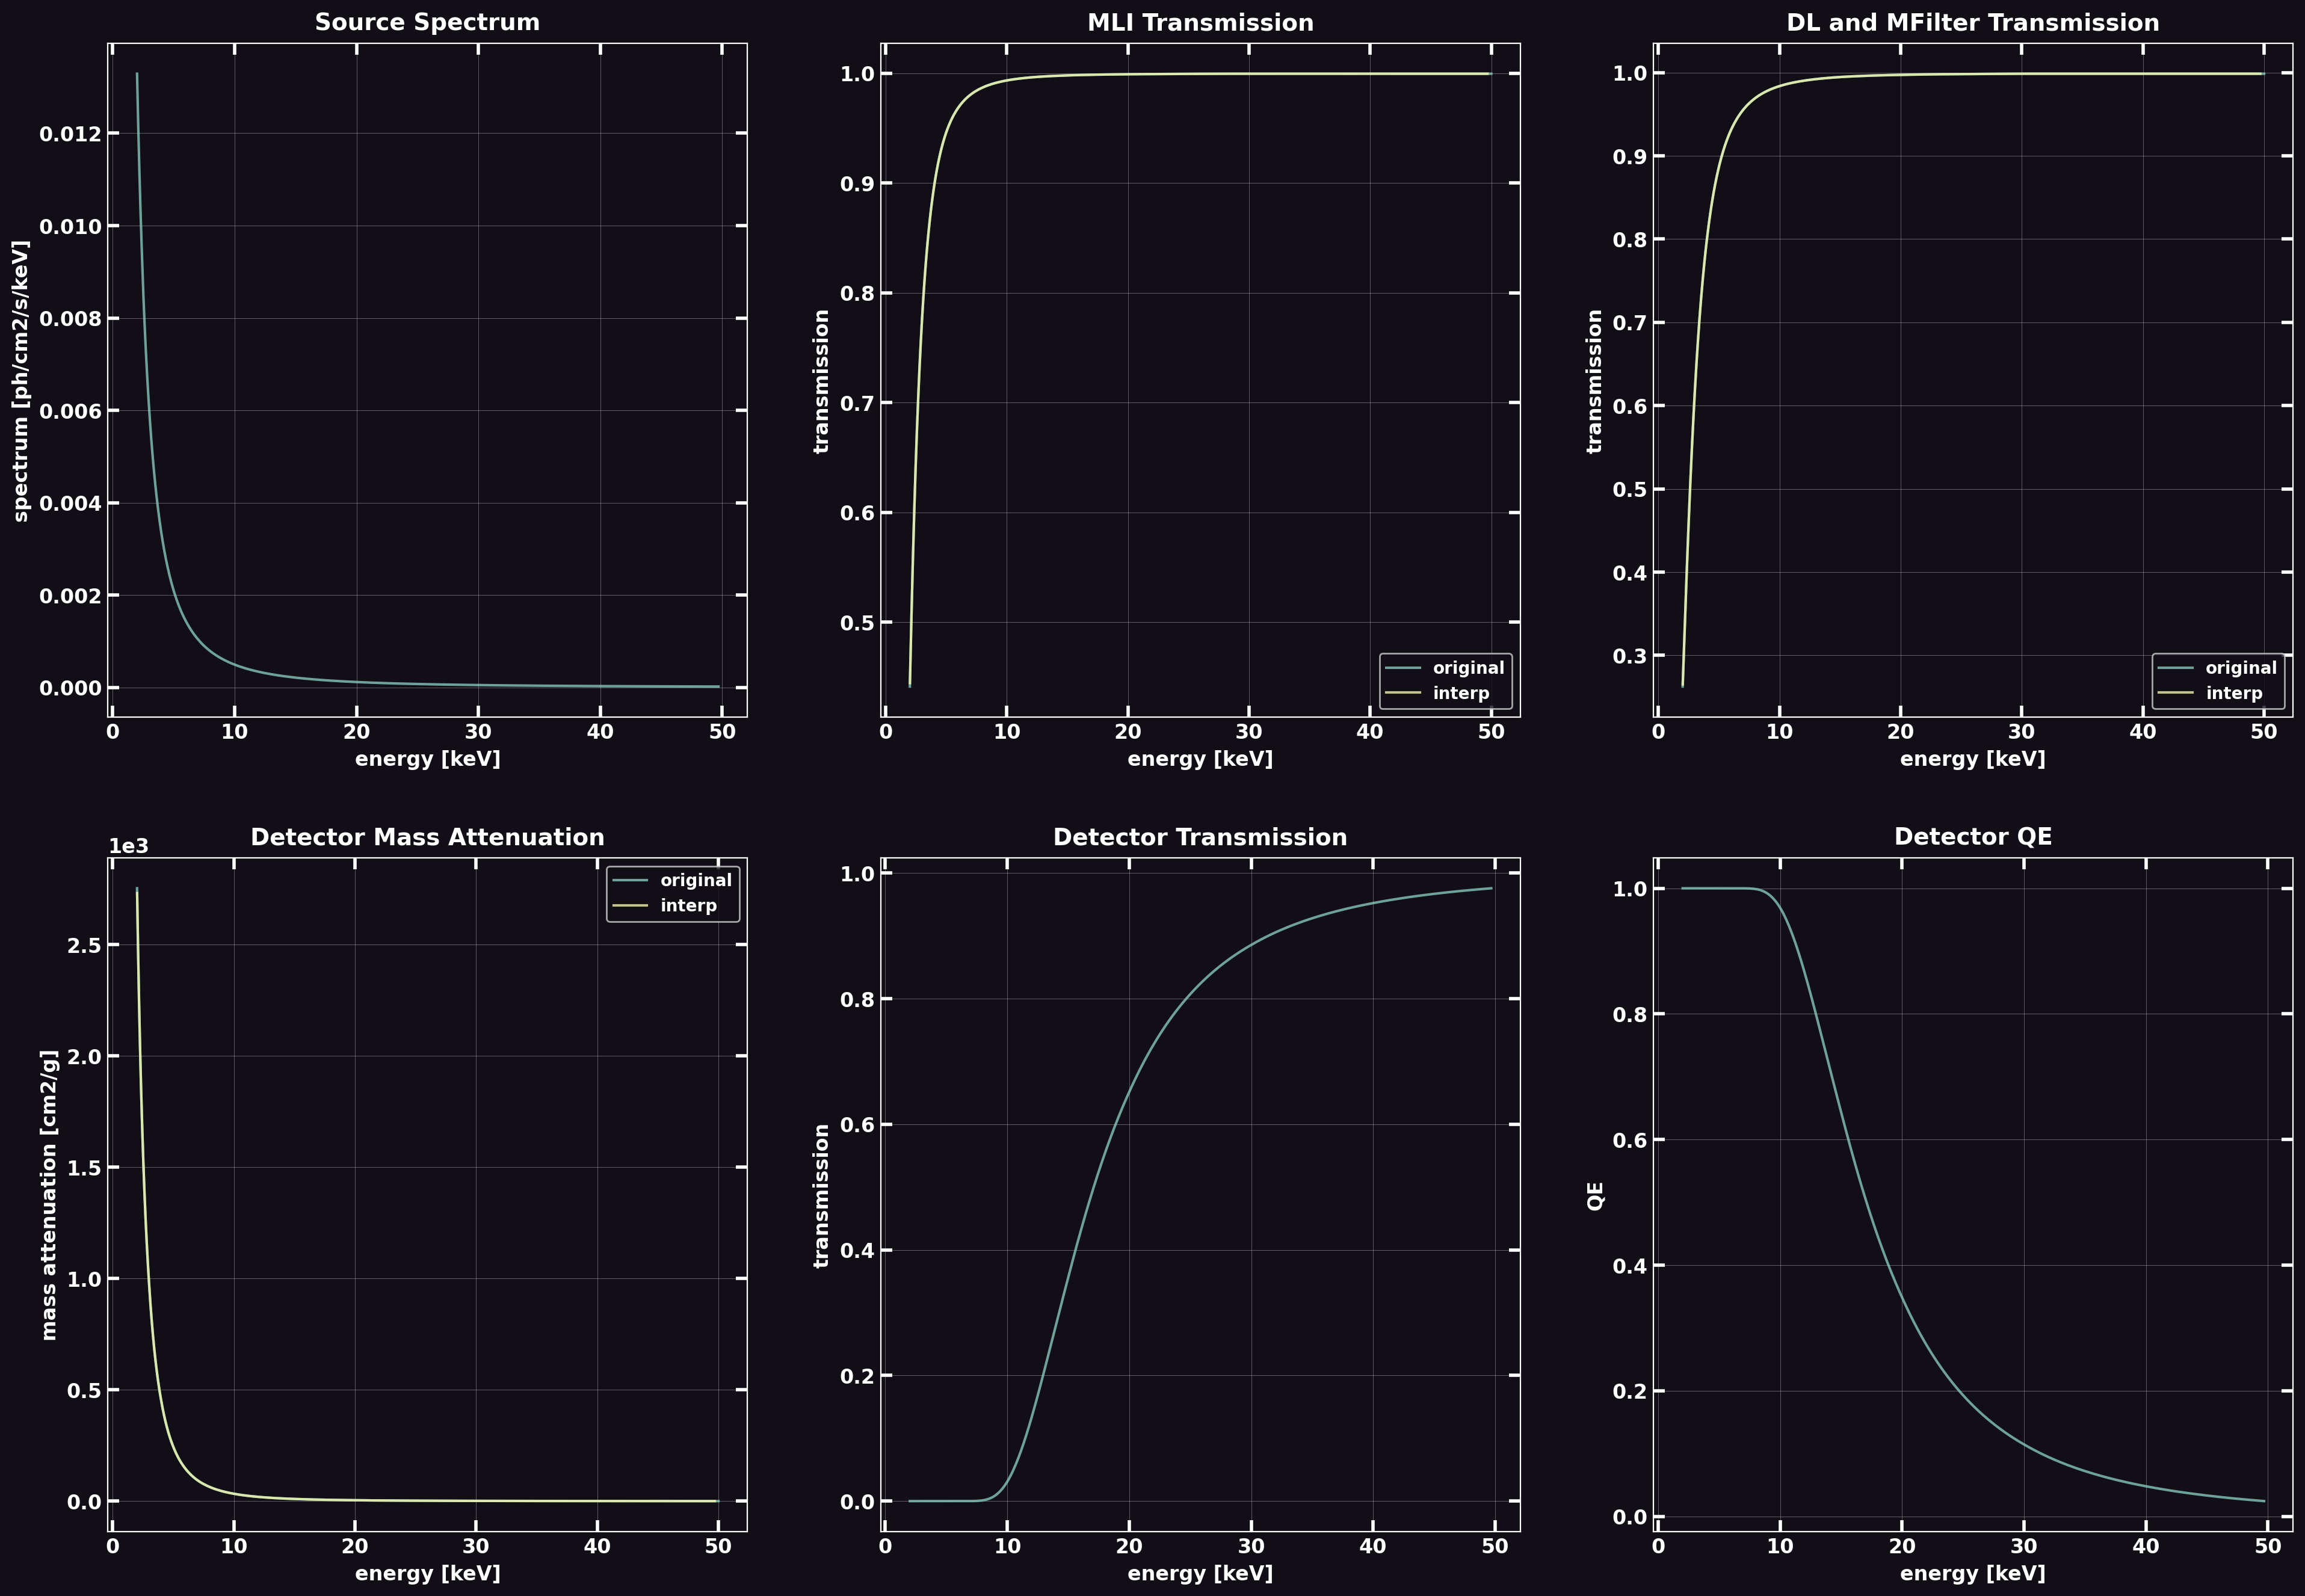

In [5]:
ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=spectrum,
            title='Source Spectrum',
            x=energy,
            xlabel='energy [keV]',
            ylabel='spectrum [ph/cm2/s/keV]',
        ),
        ds.map4plot(
            arrs=(_mli_transm, mli_transm),
            title='MLI Transmission',
            x=(_energy, energy),
            labels=('original', 'interp'),
            xlabel='energy [keV]',
            ylabel='transmission',
        ),
        ds.map4plot(
            arrs=(_dl_filter_transm, dl_filter_transm),
            title='DL and MFilter Transmission',
            x=(_energy, energy),
            labels=('original', 'interp'),
            xlabel='energy [keV]',
            ylabel='transmission',
        ),
        ds.map4plot(
            arrs=(_matten, matten),
            title='Detector Mass Attenuation',
            x=(_energy, energy),
            labels=('original', 'interp'),
            xlabel='energy [keV]',
            ylabel='mass attenuation [cm2/g]',
        ),
        ds.map4plot(
            arrs=det_transm,
            title='Detector Transmission',
            x=energy,
            xlabel='energy [keV]',
            ylabel='transmission',
        ),
        ds.map4plot(
            arrs=det_qe,
            title='Detector QE',
            x=energy,
            xlabel='energy [keV]',
            ylabel='QE',
        ),
    ),
    ncols=3,
    nrows=2,
)

In [20]:
def detector_transmission(
    x: NDArray,
    ph_energy: float,
    theta: float,
) -> NDArray:
    """
    Computes photon transmission inside material wrt the distance
    for a photon with energy `ph_energy` keV. Input polar angle is in [deg].
    """
    mu = interp_from_energy(energy, matten, ph_energy)
    return np.exp(-rho * mu * x / np.cos(np.deg2rad(theta)))

def compute_mean_dist(
    theta_x: float,
    theta_y: float,
    ph_energy: float,
    sampling: int = 10_000,
) -> float:
    """
    Computes detector mean absorption distance for a photon with `ph_energy`
    keV, coming from a given direction (`theta_x`, `theta_y`) deg wrt opt axis.
    """
    theta = compute_theta(theta_x, theta_y)
    dist_lim = 1e2  # upper lim for integral [cm]
    x: NDArray = np.linspace(0, dist_lim, sampling, endpoint=False)
    bins: NDArray = np.linspace(0, dist_lim, sampling + 1)
    t: NDArray = detector_transmission(x, ph_energy, theta)
    return integrate(x * t, np.diff(bins)) / integrate(t, np.diff(bins))


ph_energy = 25.0  # [keV]
tx, ty = 15.0, 15.0

# LoS mean absrp distance in the detector [mm]
dist: float = 10 * compute_mean_dist(tx, ty, ph_energy, int(1e4))

_theta = np.deg2rad(compute_theta(tx, ty))
print(
    f'Photon mean distance absorption: {dist:.4f} mm\n'
    f'Detector penetration: {dist * np.cos(_theta):.4f} mm\n'
    f'Impact deviation: {dist * np.sin(_theta):.4f} mm\n'
)

dsx, dsy = project_absrp_correction(dist, tx, ty)
print(f'Local-frame coords correction (x, y): {dsx:.4f}, {dsy:.4f} mm')


# to test if working:
#   - once the framework is finished, compute shadowgrams in given energy bands
#   - benchmark against WM shadowgrams in same energy bands

Photon mean distance absorption: 1.9128 mm
Detector penetration: 1.7887 mm
Impact deviation: 0.6778 mm

Local-frame coords correction (x, y): 0.4606, 0.4606 mm


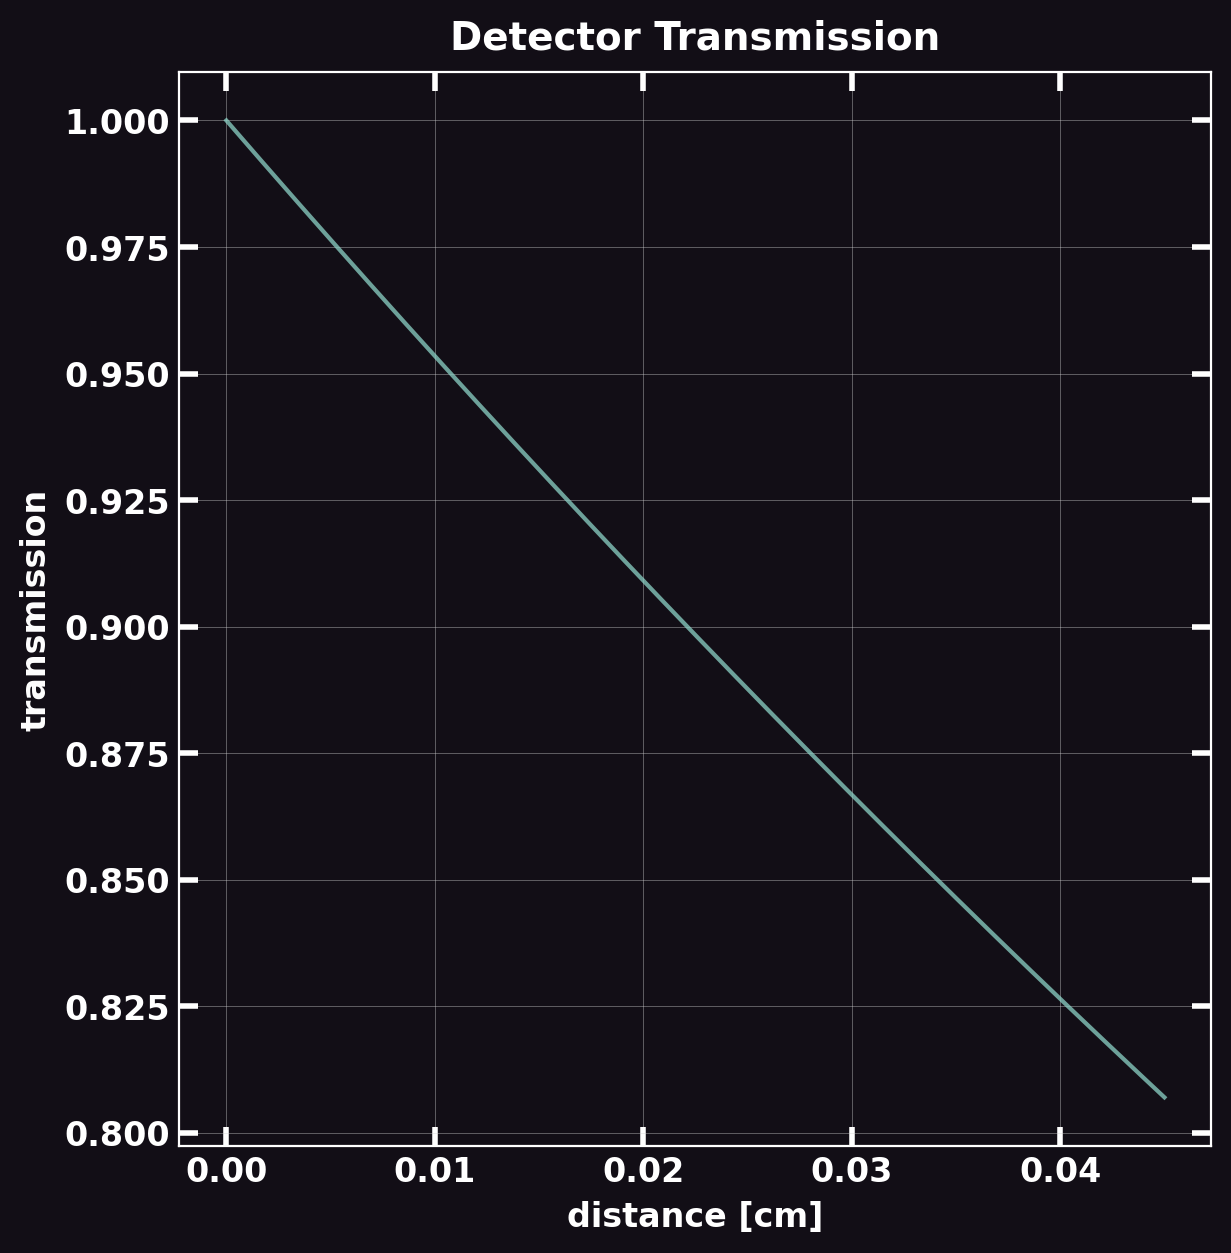

In [18]:
xi = np.linspace(0, d, int(1e6))
t = detector_transmission(xi, ph_energy, _theta)

ds.plot(
    ds.map4plot(
        arrs=t,
        title='Detector Transmission',
        x=xi,
        xlabel='distance [cm]',
        ylabel='transmission',
    ),
)